## C part (21cmFAST)

I define below some useful functions.

In [1]:
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt
import py21cmfast as p21c
from py21cmfast.inputs import global_params
from classy import Class
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy import fft
from scipy.interpolate import interp1d

def plot_box(box,ax,box_len,vmin=None, vmax=None, xlabel="x-axis [Mpc]", ylabel="y-axis [Mpc]",label=None):
    box_slice = np.take(box, 0, axis=-1)
    if vmin is None:
        vmin = np.percentile(box_slice,1)
    if vmax is None:
        vmax = np.percentile(box_slice,99)
    im = ax.imshow(box_slice,aspect='equal',origin='lower',extent= (0,box_len)*2,vmin=vmin,vmax=vmax)
    if not xlabel is None:
        ax.set_xlabel(xlabel=xlabel,fontsize=20)
    if not ylabel is None:
        ax.set_ylabel(ylabel=ylabel,fontsize=20)
    ax.xaxis.set_tick_params(labelsize=20)
    ax.yaxis.set_tick_params(labelsize=20)
    if not label is None:
        ax.text(
            0.05, 0.93,
            label,
            transform=ax.transAxes,
            va="top", ha="left",
            fontsize=20, color="black",
            bbox=dict(facecolor="white", boxstyle="round,pad=0.3")
        )
    return im

def add_color_bar_to_axis(fig,ax,cbar_label):
    cax = inset_axes(
        ax,
        width="10%",
        height="100%",
        loc="center left",
        bbox_to_anchor=(-0.4, 0., 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )
    cbar = fig.colorbar(ax.get_children()[0],cax=cax,orientation='vertical')
    cbar.ax.yaxis.set_ticks_position('left')
    cbar.ax.yaxis.set_label_position('left')
    cbar.ax.tick_params(labelsize=20)
    cbar.ax.set_ylabel(cbar_label,fontsize=20)
    return cbar

def run_21cmFAST_ICS(random_seed=1,**kwargs):
    user_params={
            "BOX_LEN": 100,
            "HII_DIM":25,
            "N_THREADS": 6,
            "NON_GAUSS_IC": False,
            "MULTIPLY_K4_WITH_TRANSFER": False
    }
    cosmo_params={
            "hlittle": 0.6736,
            "OMb": 0.0493,
            "OMm": 0.3153,
            "A_s": 2.1e-9,
            "POWER_INDEX": 0.9649,
            "tau_reio": 0.0544,
            "F_NL": 0.,
    }
    for k, v in kwargs.items():
        if k in user_params.keys():
            user_params[k] = v
        if k in cosmo_params.keys():
            cosmo_params[k] = v
    ics = p21c.initial_conditions(
        user_params=user_params,
        cosmo_params=cosmo_params,
        random_seed=random_seed,
        regenerate=True,
        write=False,
    )
    return ics

def compare_boxes(box1,box2,box_len,label1,label2):
    fig, axes = plt.subplots(1,2,figsize=(15,7))
    im1 = plot_box(
        box=box1,
        ax=axes[0],
        box_len=box_len,
        label=label1
    )
    im2 = plot_box(
        box=box2,
        ax=axes[1],
        box_len=box_len,
        vmin=im1.get_clim()[0],
        vmax=im1.get_clim()[1],
        ylabel="",
        label=label2
    )
    add_color_bar_to_axis(fig,axes[0],"$\\delta$")
    print(f"Maximum absolute difference between {label1} and {label2}: {np.abs(box1-box2).max()}")
    return fig, axes

plt.rcParams.update({"text.usetex": True, "font.family": "Times new roman"})

colors =  ['#377eb8', '#ff7f00', '#4daf4a',
           '#f781bf', '#a65628', '#984ea3',
           '#999999', '#e41a1c', '#dede00']

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

-----------------------------------------------------
SarahLibanore: developed f_nl, C files updated with IC and fcoll in Lidz approximation and DAlosio on 09/22/2025
-----------------------------------------------------


Let's run and compare boxes.

The following parameters to UserParams are not supported: ['MULTIPLY_K4_WITH_TRANSFER']
The following parameters to UserParams are not supported: ['MULTIPLY_K4_WITH_TRANSFER']


boxes->hires_density=1.254847e+00
potential=2.254896e-05
delta phi^2=-9.721042e-10
boxes->hires_density=1.257630e+00


The following parameters to UserParams are not supported: ['MULTIPLY_K4_WITH_TRANSFER']


potential=2.254896e-05
delta phi^2=-9.721042e-10
boxes->hires_density=1.257630e+00
Maximum absolute difference between box 1 and box 2: 0.03540325164794922
Maximum absolute difference between box 1 and box 3: 0.03540325164794922


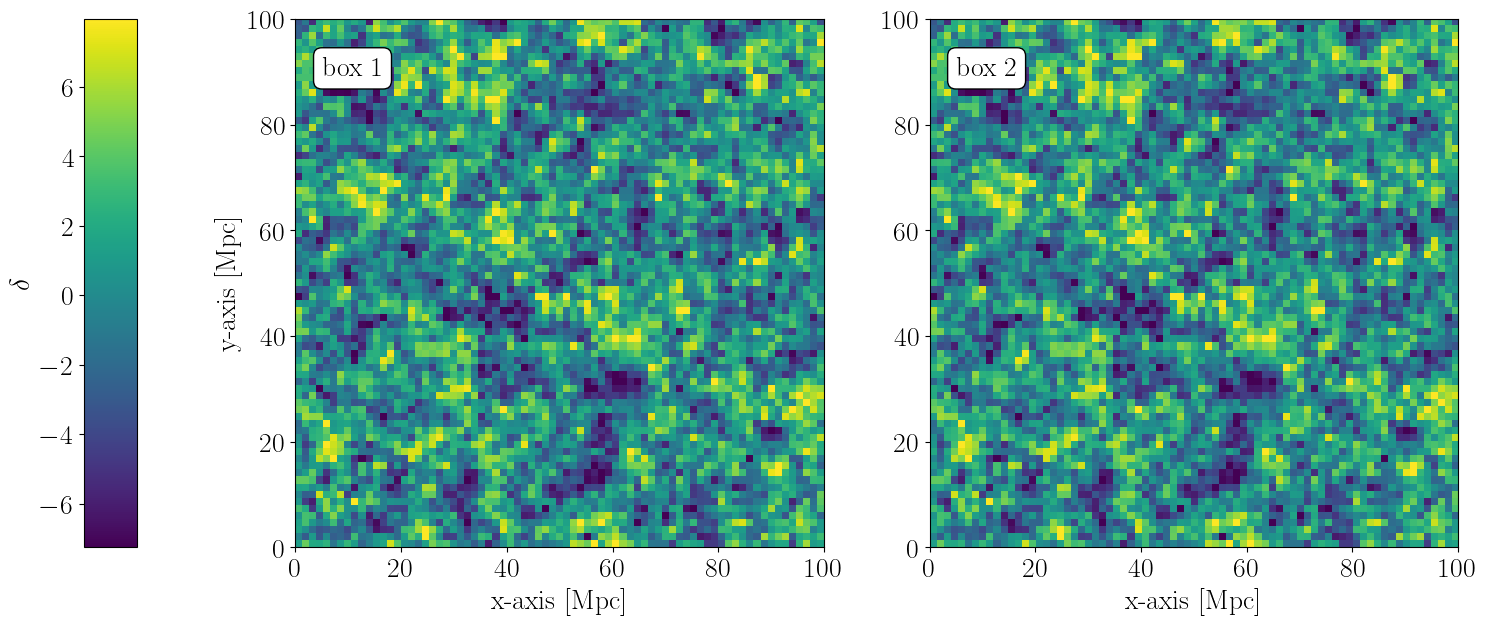

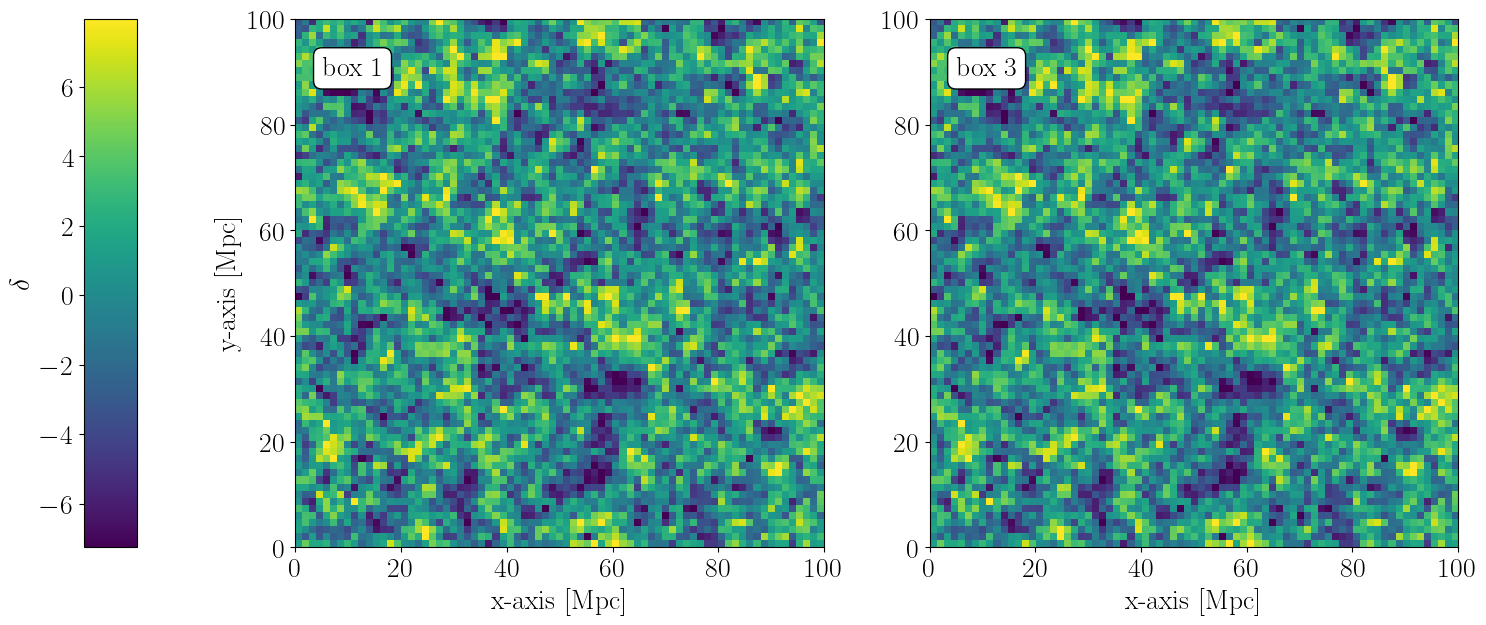

In [2]:
ics1 = run_21cmFAST_ICS(NON_GAUSS_IC=False)
ics2 = run_21cmFAST_ICS(NON_GAUSS_IC=True, F_NL=0., MULTIPLY_K4_WITH_TRANSFER=False)
ics3 = run_21cmFAST_ICS(NON_GAUSS_IC=True, F_NL=0., MULTIPLY_K4_WITH_TRANSFER=True)

box_len = ics1.user_params.BOX_LEN
compare_boxes(ics1.hires_density,ics2.hires_density,box_len,"box 1","box 2")
compare_boxes(ics1.hires_density,ics3.hires_density,box_len,"box 1","box 3");

So, the results are not affected by `MULTIPLY_K4_WITH_TRANSFER`.

## Python part

### Compute $\Phi_G$ from $\delta$

Let's repeat the calculations with python!

First, let's retrieve the transfer function and plot the matter power spectrum (just to see that we got we expect).

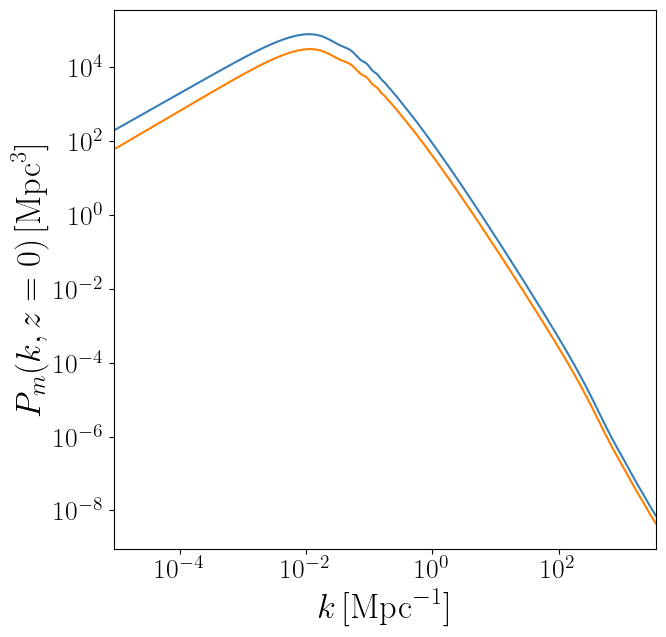

In [3]:
# We don't run_ligthcone, so the global parameters are not modified. 
# At one point, I deleted these values from the default LOG_K_ARR_FOR_TRANSFERS,
# but I didn't delete the corresponding ones in T_M0_TRANSFER, so the arrays don't match. I now add these values again.
log_k_array = np.append(global_params.LOG_K_ARR_FOR_TRANSFERS,[3.1489976 ,3.24899768,  3.34899762,  3.44899771,  3.54899762])
k_array = pow(10.,np.array(log_k_array))[1:] # 1/Mpc
T_m0_array = np.array(global_params.T_M0_TRANSFER)[1:]
k_pivot = 0.05 # 1/Mpc
P_R_array = ics1.cosmo_params.A_s * pow(k_array/k_pivot, ics1.cosmo_params.POWER_INDEX-1.)
P_m0_array =  P_R_array *2.*np.pi**2* T_m0_array**2/k_array**3
P_m0_array1 =  8.71e-10 *2.*np.pi**2* T_m0_array**2/k_array**3
# Plot matter power spectrum
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.loglog(k_array,P_m0_array)
ax.loglog(k_array,P_m0_array1)
ax.xaxis.set_tick_params(labelsize=20)
ax.yaxis.set_tick_params(labelsize=20)
ax.set_xlabel(xlabel="$k\,[\\mathrm{Mpc}^{-1}]$",fontsize=25)
ax.set_ylabel(ylabel="$P_m(k,z=0)\,[\mathrm{Mpc}^3]$",fontsize=25)
ax.set_xlim([min(k_array),max(k_array)]);

Now, given the matter transfer function, we can get the primordial gravitational potential (at matter domination) via
$$\Phi_\mathrm{G}\left(\mathbf k\right)=\frac{3}{5}\mathcal R(\mathbf k)=\frac{3}{5}\frac{\delta_\mathrm{lin}\left(\mathbf k,z=0\right)}{\mathcal T_m(k,z=0)}$$

Before calculating anything, let us define the following useful functions.

In [4]:
def get_k_mag_box(box_len,box_size):
    cell_size = box_len / box_size  # Mpc
    k_real_array = fft.rfftfreq(box_size, cell_size) * 2.0 * np.pi
    k_complex_array = fft.fftfreq(box_size, cell_size) * 2.0 * np.pi
    k_x_box, k_y_box, k_z_box = np.meshgrid(k_complex_array, k_complex_array, k_real_array, indexing="ij")
    k_mag_box = np.sqrt(k_x_box**2 + k_y_box**2 + k_z_box**2)
    return k_mag_box

def get_Transfer_box(k_mag_box,MULTIPLY_K4_WITH_TRANSFER=False):
    # Construct interpolation table for the matter transfer function
    log_k_array = np.append(global_params.LOG_K_ARR_FOR_TRANSFERS,[3.1489976 ,3.24899768,  3.34899762,  3.44899771,  3.54899762])
    k_array = pow(10.,np.array(log_k_array))
    k_array[0] = 0. # Assume the lowest wavenumber is 0, otherwise the interpolation will fail
    T_m0_array = global_params.T_M0_TRANSFER
    matter_transfer_table = interp1d(k_array,T_m0_array,kind='cubic')
    # Compute the matter transfer function on the grid
    Transfer_box = matter_transfer_table(k_mag_box)
    return Transfer_box

def get_Phi_G_box(delta_lin_box):
    # Get the Fourier transform of delta
    delta_lin_Fourier_box = fft.rfftn(delta_lin_box)
    # Get the wavenumbers associated with the box
    k_mag_box = get_k_mag_box(box_len = ics1.user_params.BOX_LEN, box_size = ics1.user_params.DIM)
    # Compute the matter transfer function on the grid
    Transfer_box = get_Transfer_box(k_mag_box)
    # Compute Phi_G
    with np.errstate(divide="ignore", invalid="ignore"):  # Don't show division by 0 warnings
        Phi_G_Fourier_box = 3./5. * delta_lin_Fourier_box/Transfer_box
    # Phi_G = delta = 0 at k=0. However, numerical errors cause the mean of the box not to be precisely zero,
    # which is why we need to manually correct this
    Phi_G_Fourier_box = np.where(k_mag_box==0, np.zeros_like(k_mag_box), Phi_G_Fourier_box)
    # Go back to real space
    Phi_G_box = fft.irfftn(Phi_G_Fourier_box,s=delta_lin_box.shape)
    return Phi_G_box

def get_delta_lin_box(Phi_G_box,MULTIPLY_K4_WITH_TRANSFER=False):
    # Get the Fourier transform of Phi_G
    Phi_G_Fourier_box = fft.rfftn(Phi_G_box)
    # Get the wavenumbers associated with the box
    k_mag_box = get_k_mag_box(box_len = ics1.user_params.BOX_LEN, box_size = ics1.user_params.DIM)
    # Compute the matter transfer function on the grid
    Transfer_box = get_Transfer_box(k_mag_box,MULTIPLY_K4_WITH_TRANSFER)
    if MULTIPLY_K4_WITH_TRANSFER:
        Transfer_box *= pow(k_mag_box,4)
    # Compute delta_lin
    delta_lin_Fourier_box2 = 5./3. * Phi_G_Fourier_box * Transfer_box
    # Go back to real space
    delta_lin_box = fft.irfftn(delta_lin_Fourier_box2, s=Phi_G_box.shape)
    return delta_lin_box

And now we compute $\Phi_G$.

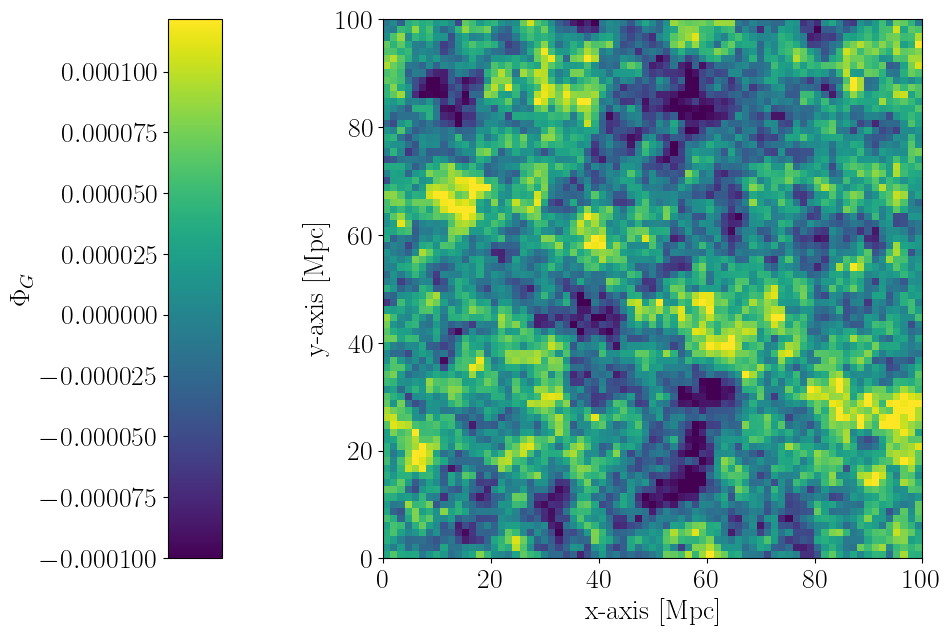

In [5]:
Phi_G_box = get_Phi_G_box(delta_lin_box = ics1.hires_density)

# Plot Phi_G
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
im1 = plot_box(
    box=Phi_G_box,
    ax=ax,
    box_len=ics1.user_params.BOX_LEN,
)
add_color_bar_to_axis(fig,ax,"$\\Phi_G$");